# Display false-color

This section builds a **2x3 diagnostic panel** for every ENVI hyperspectral cube found in `data/`.

For each `.hdr` dataset, the notebook automatically generates:

1. **True Color (RGB)** as a visual baseline.
2. **Water Emphasis** (NIR-Red-Green), where open water usually appears darker because water absorbs strongly in NIR.
3. **Urban/Built-up Emphasis** (RedEdge-NIR-Blue), helping separate bright impervious surfaces from vegetation.
4. **Forest Vigor** (NIR-RedEdge-Green), which makes dense healthy vegetation stand out.
5. **Dry Soil / Bare Field** (Red-NIR-Green), often increasing contrast for exposed dry soil and harvested fields.
6. **Moisture Stress** (RedEdge-Red-Green), useful for spotting stressed vegetation and moisture differences.

The code reads wavelengths from ENVI metadata and picks the **closest available band** to each target wavelength.
Each channel is stretched using robust percentiles (2-98%) to improve visual interpretability.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import spectral.io.envi as envi

DATA_DIR = Path('data')
HDR_FILES = sorted(DATA_DIR.glob('*.hdr'))

if not HDR_FILES:
    raise FileNotFoundError(f'No .hdr files found in {DATA_DIR.resolve()}')

print(f'Found {len(HDR_FILES)} header files:')
for p in HDR_FILES:
    print(' -', p.name)


def parse_wavelengths(meta):
    wl = meta.get('wavelength')
    if not wl:
        return None
    try:
        return np.array([float(v) for v in wl], dtype=float)
    except (TypeError, ValueError):
        return None


def get_ignore_value(meta):
    raw = meta.get('data ignore value')
    if raw is None:
        return None
    try:
        return float(str(raw).strip())
    except ValueError:
        return None


def nearest_band_index(wavelengths, target_nm, nbands):
    if wavelengths is None or len(wavelengths) != nbands:
        # fallback: evenly distributed pseudo-selection if wavelengths are unavailable
        return int(np.clip(round((target_nm - 450) / (950 - 450) * (nbands - 1)), 0, nbands - 1))
    return int(np.argmin(np.abs(wavelengths - target_nm)))


def robust_stretch(channel):
    finite = np.isfinite(channel)
    if not finite.any():
        return np.zeros_like(channel, dtype=float)
    p2, p98 = np.nanpercentile(channel, [2, 98])
    return np.clip((channel - p2) / max(p98 - p2, 1e-6), 0, 1)


def compose_rgb(img, indices, ignore_value=None):
    cube = img.read_bands(indices).astype(np.float32)
    if ignore_value is not None:
        cube[cube == ignore_value] = np.nan
    cube[cube < 0] = np.nan

    out = np.zeros_like(cube, dtype=float)
    for c in range(3):
        out[:, :, c] = robust_stretch(cube[:, :, c])
    return np.nan_to_num(out, nan=0.0)


Found 3 header files:
 - 221000_Odra_HS_Blok_A_008_VS_join_atm.hdr
 - 221000_Odra_HS_Blok_A_013_VS_join_atm.hdr
 - 221000_Odra_HS_Blok_A_015_VS_join_atm.hdr


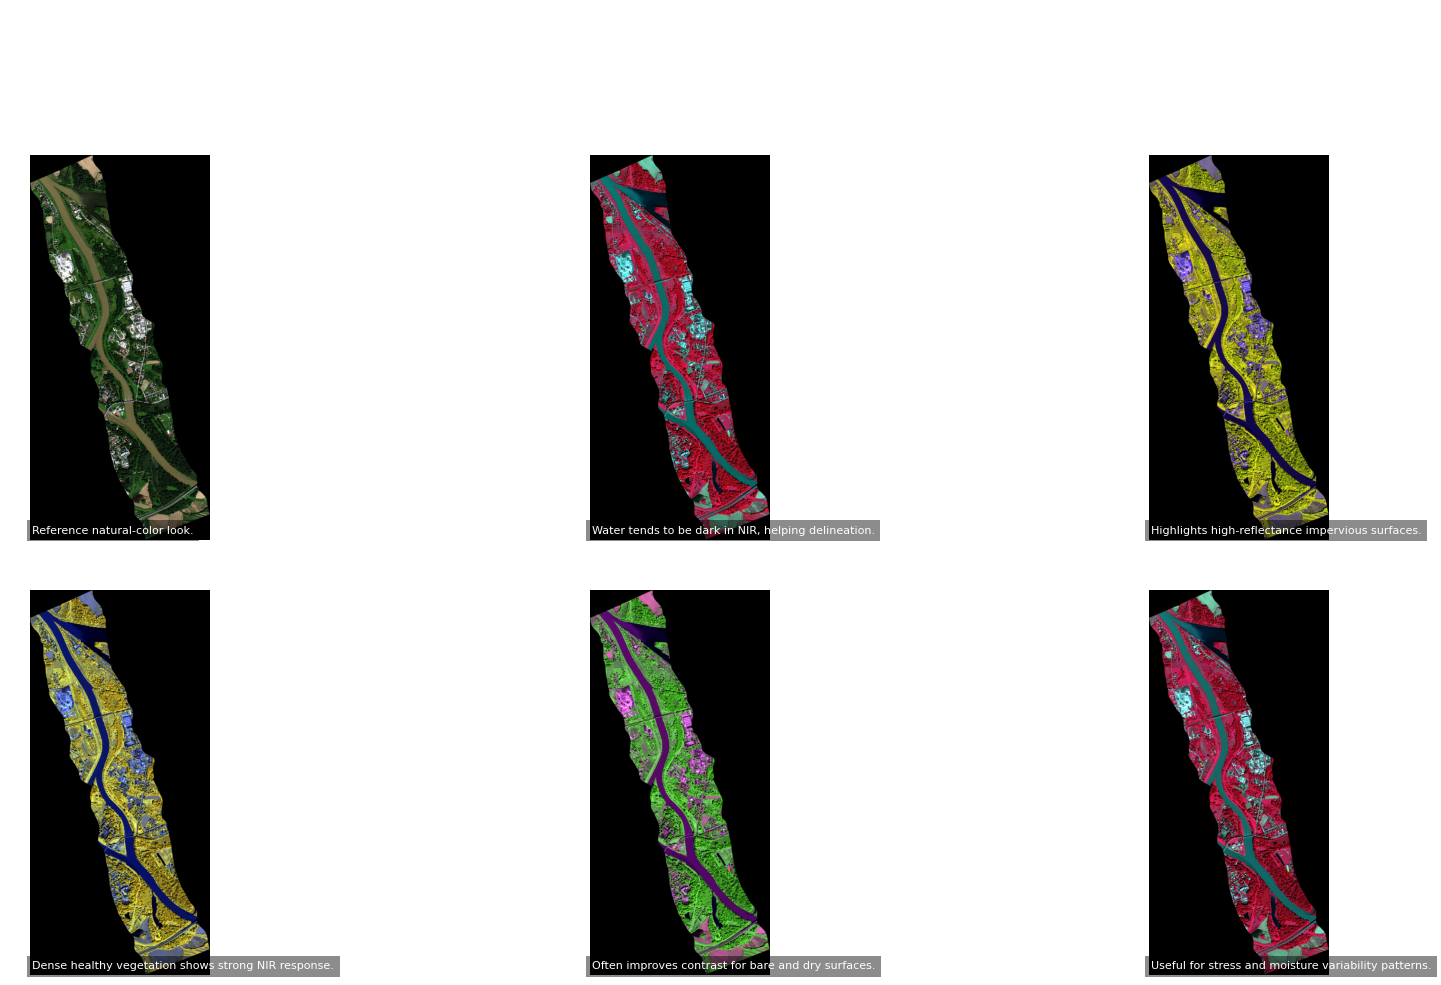

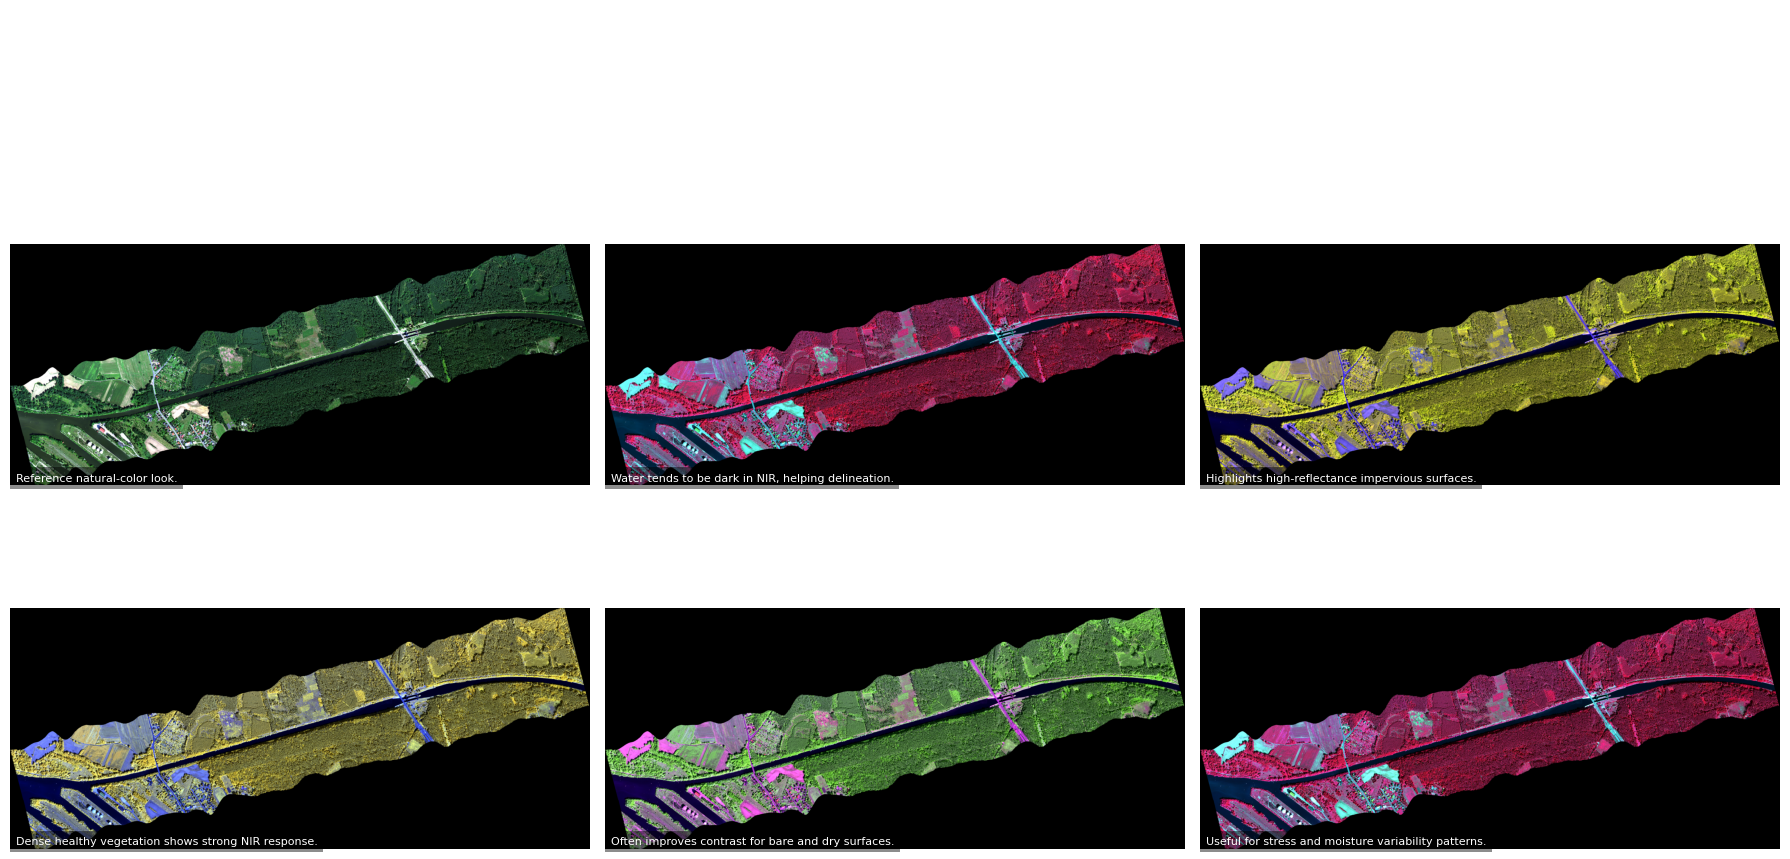

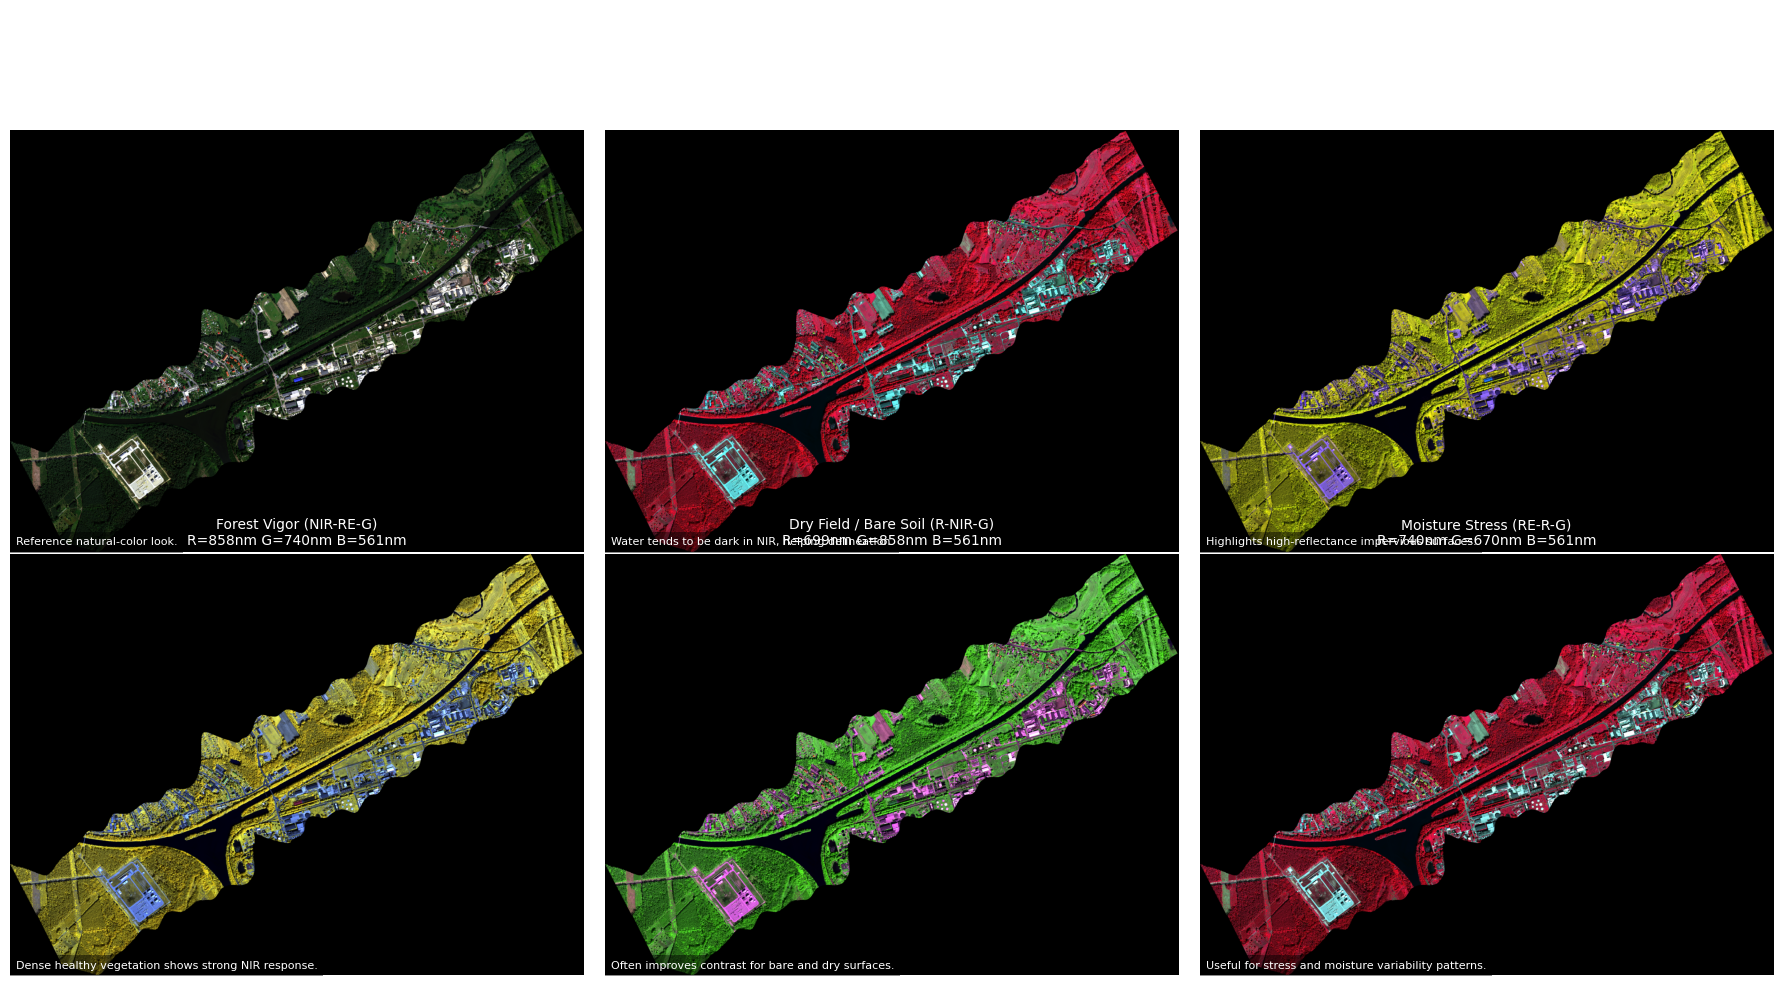

In [2]:
# Target composite definitions: (R_nm, G_nm, B_nm)
COMPOSITES = [
    ('True Color (RGB)', (650, 560, 470), 'Reference natural-color look.'),
    ('Water Emphasis (NIR-R-G)', (860, 660, 560), 'Water tends to be dark in NIR, helping delineation.'),
    ('Urban / Built-up (RE-NIR-B)', (740, 860, 490), 'Highlights high-reflectance impervious surfaces.'),
    ('Forest Vigor (NIR-RE-G)', (860, 740, 560), 'Dense healthy vegetation shows strong NIR response.'),
    ('Dry Field / Bare Soil (R-NIR-G)', (700, 860, 560), 'Often improves contrast for bare and dry surfaces.'),
    ('Moisture Stress (RE-R-G)', (740, 670, 560), 'Useful for stress and moisture variability patterns.'),
]

for hdr in HDR_FILES:
    img = envi.open(str(hdr))
    meta = img.metadata
    wavelengths = parse_wavelengths(meta)
    ignore_value = get_ignore_value(meta)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.patch.set_facecolor('white')

    for ax, (name, (r_nm, g_nm, b_nm), comment) in zip(axes.ravel(), COMPOSITES):
        r_idx = nearest_band_index(wavelengths, r_nm, img.nbands)
        g_idx = nearest_band_index(wavelengths, g_nm, img.nbands)
        b_idx = nearest_band_index(wavelengths, b_nm, img.nbands)

        rgb = compose_rgb(img, [r_idx, g_idx, b_idx], ignore_value=ignore_value)
        ax.imshow(rgb)
        ax.axis('off')

        if wavelengths is not None and len(wavelengths) == img.nbands:
            title = (
                f"{name}\n"
                f"R={wavelengths[r_idx]:.0f}nm G={wavelengths[g_idx]:.0f}nm B={wavelengths[b_idx]:.0f}nm"
            )
        else:
            title = f"{name}\nR={r_idx} G={g_idx} B={b_idx}"

        ax.set_title(title, fontsize=10)
        ax.text(
            0.01,
            0.01,
            comment,
            transform=ax.transAxes,
            fontsize=8,
            color='white',
            ha='left',
            va='bottom',
            bbox=dict(facecolor='black', alpha=0.45, edgecolor='none', pad=4),
        )

    fig.suptitle(
        f"False-color panel for: {hdr.name}\n"
        f"shape={img.nrows}x{img.ncols}x{img.nbands}, ignore={ignore_value}",
        fontsize=13,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


# Calculate water quality indices

This section computes three **hyperspectral proxy indices** for water quality over the airborne cubes.

- **Chl-a proxy**: `NDCI = (R705 - R665) / (R705 + R665)`
- **DOC proxy**: green-blue contrast `(R560 - R443) / (R560 + R443)`
- **Turbidity proxy**: red-green contrast `(R665 - R560) / (R665 + R560)`

The maps are shown only for **water-like pixels**, detected here with a simple spectral mask `R560 > R865`.
These outputs should be treated as **relative indicators / proxies**, not calibrated concentrations in physical units.


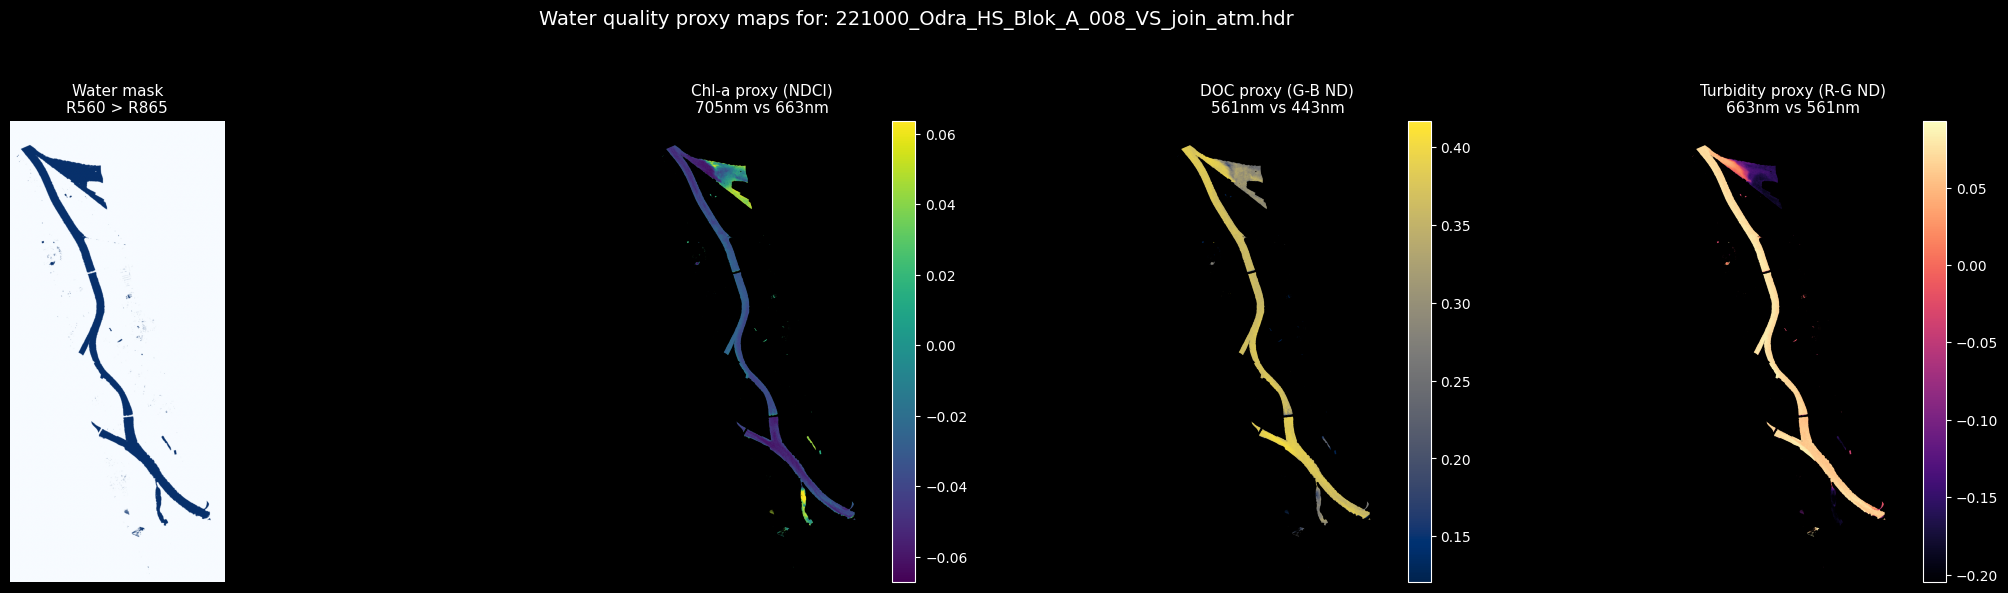

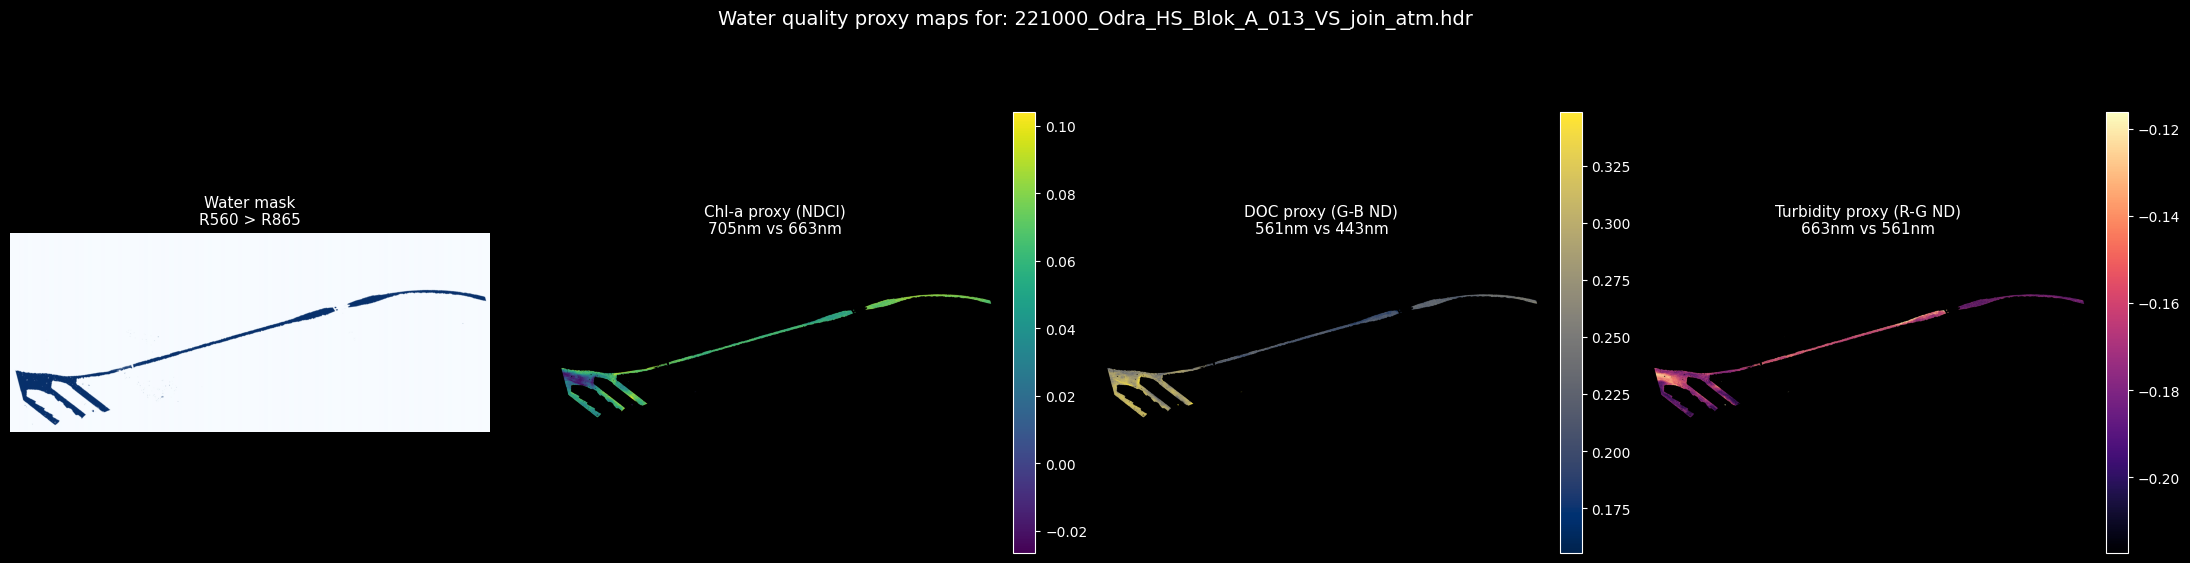

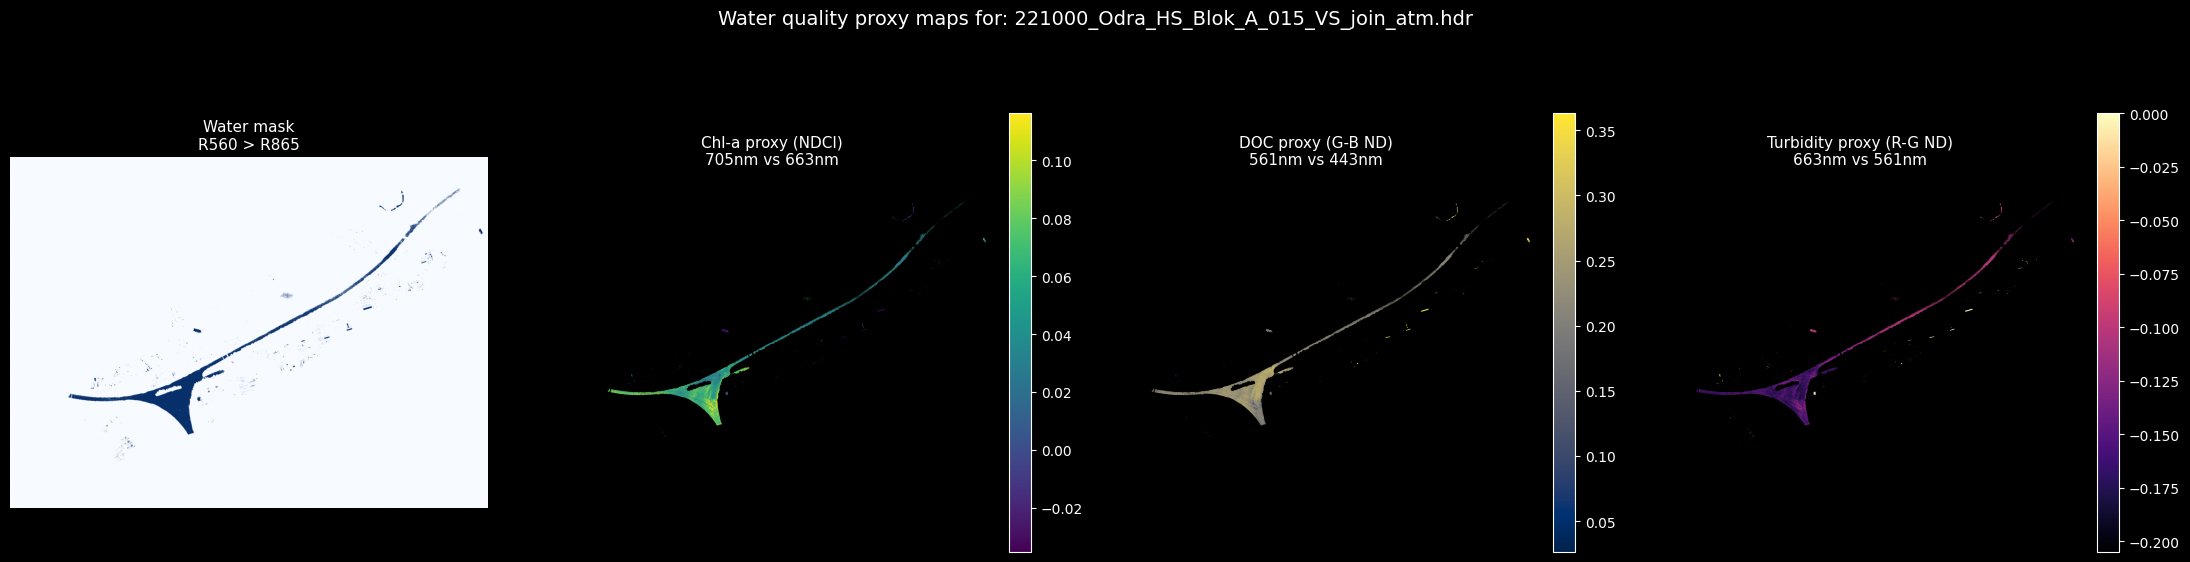

In [3]:
def read_band(img, wavelengths, target_nm, ignore_value=None, scale=10000.0):
    idx = nearest_band_index(wavelengths, target_nm, img.nbands)
    band = img.read_band(idx).astype(np.float32)
    if ignore_value is not None:
        band[band == ignore_value] = np.nan
    band[band < 0] = np.nan
    return idx, band / scale


def nd(a, b):
    return np.divide(a - b, a + b, out=np.full_like(a, np.nan), where=np.abs(a + b) > 1e-6)


INDEX_SPECS = [
    ('Chl-a proxy (NDCI)', 705, 665, 'viridis'),
    ('DOC proxy (G-B ND)', 560, 443, 'cividis'),
    ('Turbidity proxy (R-G ND)', 665, 560, 'magma'),
]

for hdr in HDR_FILES:
    img = envi.open(str(hdr))
    meta = img.metadata
    wavelengths = parse_wavelengths(meta)
    ignore_value = get_ignore_value(meta)
    scale = float(meta.get('reflectance scale factor', 10000.0))

    bands = {nm: read_band(img, wavelengths, nm, ignore_value, scale) for nm in {443, 560, 665, 705, 865}}
    water_mask = np.isfinite(bands[560][1]) & np.isfinite(bands[865][1]) & (bands[560][1] > bands[865][1])

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    axes[0].imshow(water_mask, cmap='Blues')
    axes[0].set_title('Water mask\nR560 > R865', fontsize=11)
    axes[0].axis('off')

    for ax, (label, hi_nm, lo_nm, cmap) in zip(axes[1:], INDEX_SPECS):
        hi_idx, hi = bands[hi_nm]
        lo_idx, lo = bands[lo_nm]
        index_map = nd(hi, lo)
        index_map[~water_mask] = np.nan
        finite = np.isfinite(index_map)
        vmin, vmax = np.nanpercentile(index_map[finite], [2, 98]) if finite.any() else (0.0, 1.0)
        band_note = (
            f'{wavelengths[hi_idx]:.0f}nm vs {wavelengths[lo_idx]:.0f}nm'
            if wavelengths is not None and len(wavelengths) == img.nbands
            else f'band {hi_idx} vs {lo_idx}'
        )

        im = ax.imshow(index_map, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f'{label}\n{band_note}', fontsize=11)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f'Water quality proxy maps for: {hdr.name}', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()
